In [1]:
import torch
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import lightning.pytorch as pl
from lightning.pytorch.callbacks import RichProgressBar, Timer, LearningRateFinder
import omegaconf


# Add the prime_torch file to the system path so we can import it
import sys
sys.path.append("/glade/u/home/cobrien/prime/prime_lib/primesw")
from data import SWDataset, SWDataModule
from prime_torch import crps, SWRegressor

In [2]:
teststore = pd.HDFStore("/glade/u/home/cobrien/prime/scripts/primeps_outputs.h5")
teststore.keys()

['/psflex20_version2',
 '/psflex20_version2_storm',
 '/psflex_version3',
 '/psflex_version3_storm',
 '/pshigh_version24',
 '/pshigh_version24_storm',
 '/psmms_version4',
 '/psmms_version4_storm',
 '/psmms_version5',
 '/psmms_version5_storm',
 '/psmms_version6',
 '/psmms_version6_storm',
 '/psstrict20_version2',
 '/psstrict20_version2_storm',
 '/psstrict_version1',
 '/psstrict_version1_storm',
 '/psstrict_version6',
 '/psstrict_version6_storm']

In [3]:
torch.set_float32_matmul_precision('medium')

config = '/glade/u/home/cobrien/prime/prime_lib/configs/plasmasheet_strict.yaml' # '/glade/u/home/cobrien/prime/prime_lib/configs/plasmasheet_mms.yaml' # '/glade/u/home/cobrien/prime/prime_lib/configs/plasmasheet_strict.yaml'
cfg = omegaconf.OmegaConf.load(
    config
)

# Running .setup() with this DataModule will take like an hour. Find a way to cache this dataloader
datamodule = SWDataModule(
    target_features = cfg.data.target_features,
    input_features = cfg.data.input_features,
    position_features = cfg.data.position_features,
    interp_flags = cfg.data.interp_flags,
    region = cfg.data.region,
    cuts = cfg.data.cuts,
    cadence = cfg.data.cadence,
    interpolate = cfg.data.interpolate,
    window = cfg.data.window,
    stride = cfg.data.stride,
    interp_frac = cfg.data.interp_frac,
    trn_bounds = ['20150822 02:55:00+0000', '20150824 02:55:00+0000'],#cfg.data.trn_bounds,
    val_bounds = ['20150822 02:55:00+0000', '20150824 02:55:00+0000'],# cfg.data.val_bounds,
    tst_bounds = cfg.data.tst_bounds,
    batch_size = cfg.opt.batch_size,
    num_workers = cfg.opt.num_workers,
    datastore = cfg.data.datastore,
    in_key = cfg.data.in_key,
    tar_key = cfg.data.tar_key,
    scaler_type = cfg.data.scaler_type,
)
# datamodule.setup()

model = SWRegressor.load_from_checkpoint(
    # "/glade/u/home/cobrien/data/prime/tensorboard_logs/pstesting/version_24/checkpoints/epoch=199-step=11000.ckpt"
    # "/glade/u/home/cobrien/data/prime/tensorboard_logs/psstrict/version_2/checkpoints/epoch=199-step=10200.ckpt"
    # "/glade/u/home/cobrien/data/prime/tensorboard_logs/psstrict/version_1/checkpoints/epoch=199-step=11000.ckpt"
    # "/glade/u/home/cobrien/data/prime/tensorboard_logs/psmms/version_2/checkpoints/epoch=199-step=1600.ckpt"
    # "/glade/u/home/cobrien/data/prime/tensorboard_logs/psflex/version_3/checkpoints/epoch=199-step=27600.ckpt"
    # "/glade/u/home/cobrien/data/prime/tensorboard_logs/psflex/version_2/checkpoints/epoch=199-step=25800.ckpt"
    # "/glade/u/home/cobrien/data/prime/tensorboard_logs/psmms/version_1/checkpoints/epoch=199-step=1600.ckpt"
    # "/glade/u/home/cobrien/data/prime/checkpoints/psmms_plasmasheet_mmstemp.ckpt"
    # "/glade/u/home/cobrien/data/prime/tensorboard_logs/psmms/version_6/checkpoints/epoch=799-step=6400.ckpt"
    # "/glade/u/home/cobrien/data/prime/tensorboard_logs/psmms/version_5/checkpoints/epoch=499-step=4000.ckpt"
    "/glade/u/home/cobrien/data/prime/tensorboard_logs/psstrict/version_6/checkpoints/epoch=299-step=16500.ckpt"
)
model.eval() # Disables randomness, dropout, gradients

/glade/work/cobrien/conda-envs/pt212gpu_conda/lib/python3.11/site-packages/torch/cuda/__init__.py:611: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


SWRegressor(
  (trn_mae): ProbabilisticMeanAbsoluteError()
  (val_mae): ProbabilisticMeanAbsoluteError()
  (tst_mae): ProbabilisticMeanAbsoluteError()
  (encoder): RecurrentEncoder(
    (network): RNN(14, 256, num_layers=2, batch_first=True, dropout=0.2)
  )
  (decoder): LinearDecoder(
    (network): Sequential(
      (0): Linear(in_features=268, out_features=256, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=256, out_features=128, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.2, inplace=False)
      (6): Linear(in_features=128, out_features=64, bias=True)
      (7): ReLU()
      (8): Dropout(p=0.2, inplace=False)
      (9): Linear(in_features=64, out_features=4, bias=True)
    )
  )
)

In [4]:
# Load the data
wind_data = pd.read_hdf('/glade/u/home/cobrien/data/magnetotail/resampled_datasets.h5', key = 'wind_full', mode = 'r')
# print(wind_data.std())
themis_data = pd.read_csv('/glade/u/home/cobrien/data/themis/combined_loc_themis_cleaned.csv', index_col=None)
themis_data = themis_data.drop(index = [0,1])
themis_data['datetime'] = pd.to_datetime(themis_data['datetime'], utc = True)

In [ ]:
# Make the position inputs and cut the input wind data to just the interval covered by the themis data
wind_data = wind_data.loc[
    (wind_data['Epoch'] <= themis_data['datetime'].max() - pd.Timedelta(seconds = (model.stride) * 100))&
    (wind_data['Epoch'] >= themis_data['datetime'].min() - pd.Timedelta(seconds = (model.stride + model.window) * 100)),
    :
]
positions = pd.DataFrame(wind_data['Epoch'], columns = ['Epoch'])
positions['Rx_int'] = np.interp(positions['Epoch'], themis_data['datetime'], themis_data['X_GSM'])
positions['Ry_int'] = np.interp(positions['Epoch'], themis_data['datetime'], themis_data['Y_GSM'])
positions['Rz_int'] = np.interp(positions['Epoch'], themis_data['datetime'], themis_data['Z_GSM'])
# positions['r_gsm_x'] = np.interp(positions['Epoch'], themis_data['datetime'], themis_data['X_GSM'])
# positions['r_gsm_y'] = np.interp(positions['Epoch'], themis_data['datetime'], themis_data['Y_GSM'])
# positions['r_gsm_z'] = np.interp(positions['Epoch'], themis_data['datetime'], themis_data['Z_GSM'])

In [6]:
# model.in_norm = datamodule.input_normalizations
# model.pos_norm = datamodule.position_normalizations
prime_data = model.predict_df(wind_data, positions)

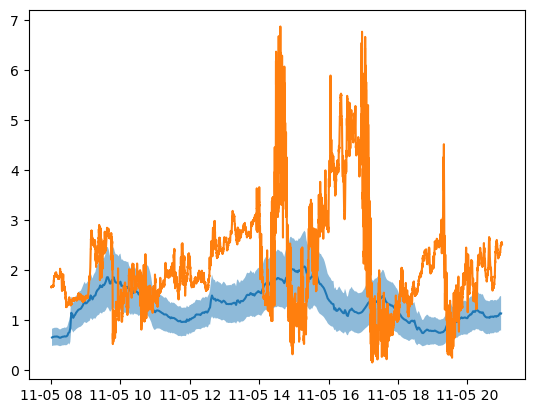

In [7]:
import matplotlib.pyplot as plt

plt.plot(prime_data['Epoch'], prime_data['N'])
plt.fill_between(prime_data['Epoch'], prime_data['N'] - prime_data['N_std'], prime_data['N'] + prime_data['N_std'], alpha = 0.5)
plt.plot(themis_data['datetime'], themis_data['density'])

# plt.plot(prime_data['Epoch'], prime_data['T_i_over_T_e'])
# plt.fill_between(prime_data['Epoch'], prime_data['T_i_over_T_e'] - prime_data['T_i_over_T_e_std'], prime_data['T_i_over_T_e'] + prime_data['T_i_over_T_e_std'], alpha = 0.5)
# plt.plot(themis_data['datetime'], themis_data['ratio'])

In [ ]:
# prime_data.to_hdf("/glade/u/home/cobrien/prime/scripts/primeps_outputs.h5", key = "psstrict_version6_storm")

In [53]:
model.tar_norm

# Version 7
# {'N': (0.4513633866274092, 0.8961303138350295),
#  'temp': (4341.372569394547, 2439.7238682921293)}
# {'Ni': (7.575942, 1635.399),
#  'Vi_xgse': (-421.1689, 104.84078),
#  'Vi_ygse': (-1.1496662, 61.705624),
#  'Vi_zgse': (-2.79055, 45.4899),
#  'Vth': (36.56218, 18.75177),
#  'R_xgse': (180.33188, 90.915596),
#  'R_ygse': (-1.7973562, 80.85694),
#  'R_zgse': (1.9249461, 12.063982),
#  'B_xgsm': (-0.061672468, 5.62544),
#  'B_ygsm': (0.16372976, 6.1474695),
#  'B_zgsm': (0.00834217, 6.5854907),
#  'SME': (223.32116705400375, 225.9355978286592),
#  'SMR': (-7.750147104476214, 18.173108763733058),
#  'tilt': (0.20978173066208744, 17.785085176785703)}

# Version 12
# {'N': (0.4513633866274092, 0.8961303138350295),
#  'temp': (4341.372569394547, 2439.7238682921293)}
# {'Ni': (7.575942, 1635.399),
#  'Vi_xgse': (-421.1689, 104.84078),
#  'Vi_ygse': (-1.1496662, 61.705624),
#  'Vi_zgse': (-2.79055, 45.4899),
#  'Vth': (36.56218, 18.75177),
#  'R_xgse': (180.33188, 90.915596),
#  'R_ygse': (-1.7973562, 80.85694),
#  'R_zgse': (1.9249461, 12.063982),
#  'B_xgsm': (-0.061672468, 5.62544),self
#  'B_ygsm': (0.16372976, 6.1474695),
#  'B_zgsm': (0.00834217, 6.5854907),
#  'SME': (223.32116705400375, 225.9355978286592),
#  'SMR': (-7.750147104476214, 18.173108763733058),
#  'tilt': (0.20978173066208744, 17.785085176785703)}

{'T_i': (5601.745795454545, 3484.258895059289),
 'T_e': (1176.3849931196733, 1111.1102570967241),
 'T_i_over_T_e': (4.866328626871109, 2.3983716314489194)}

In [62]:
# Synthetic SW 2D maps
# Init synthetic solar wind datastructures
synth_data = pd.DataFrame(np.zeros((model.window+1, len(datamodule.input_features))), columns = datamodule.input_features)
# synth_data['Epoch'] = pd.to_datetime('2000-01-01 00:00:00+0000') # This time is unused, but model.predict() throws a warning when input data has no Epoch
synth_pos = pd.DataFrame(np.zeros((model.window+1, 3)), columns = datamodule.position_features)

synth_overrides = {
    'Ni' : 3,
    'Vi_xgse' : -380,
    'Vi_ygse' : - 30,
    'Vi_zgse' : -2.8,
    'Vth' : 36,
    'R_xgse' : 197.8,
    'R_ygse' : -0.03,
    'R_zgse' : -10.7,
    'B_xgsm' : -0.06,
    'B_ygsm' : 0.16,
    'B_zgsm' : -5,
    'SME' : 200,
    'SMR' : 0,
    'tilt' : 15,
}

# Override the prior values (currently empty) with new synthetic conditions
for key in synth_overrides.keys():
    synth_data[key] = synth_overrides[key]

In [63]:
# Define the grid extent
x_extent = [-15, 0]
y_extent = [-12.5, 12.5]
gridsize = 1
r_cut = 10 # Cut out this many RE from Earth where the outputs are invalid

# Pick the solar wind conditions we're iterating over
# bz = [-5, 5, -5, 5]
# # ni = [3, 3, 20, 20]
# vx = [-300, -300, -600, -600]

# Dubyagin plot:
bz = [0, -2, 2, 2]
vx = [-400, -400, -400, -600]

# Initialize the grid
x_arr = np.arange(x_extent[0], x_extent[1], gridsize)
y_arr = np.arange(y_extent[0], y_extent[1], gridsize)
output_grid = np.zeros((len(bz), len(x_arr), len(y_arr), len(datamodule.target_features)*2))

for k in range(len(bz)):
    synth_data['B_zgsm'] = bz[k] # Set new SW conditions for this frame
    # synth_data['Ni'] = ni[k]
    synth_data['Vi_xgse'] = vx[k]
    for i, x in enumerate(x_arr):
        for j, y in enumerate(y_arr):
            synth_pos[datamodule.position_features[0]] = x
            synth_pos[datamodule.position_features[1]] = y
            if np.sqrt(x**2 + y**2) < r_cut:
                output_grid[k, i, j, :] = np.nan
            else:
                output_grid[k, i, j, :] = model.predict_df(synth_data, synth_pos)

/glade/u/home/cobrien/prime/prime_lib/primesw/prime_torch.py:184: UserWarning: timeseries DataFrame does not have Epoch key, no time data will be returned
  warnings.warn('timeseries DataFrame does not have Epoch key, no time data will be returned')
/glade/u/home/cobrien/prime/prime_lib/primesw/prime_torch.py:184: UserWarning: timeseries DataFrame does not have Epoch key, no time data will be returned
  warnings.warn('timeseries DataFrame does not have Epoch key, no time data will be returned')
/glade/u/home/cobrien/prime/prime_lib/primesw/prime_torch.py:184: UserWarning: timeseries DataFrame does not have Epoch key, no time data will be returned
  warnings.warn('timeseries DataFrame does not have Epoch key, no time data will be returned')
/glade/u/home/cobrien/prime/prime_lib/primesw/prime_torch.py:184: UserWarning: timeseries DataFrame does not have Epoch key, no time data will be returned
  warnings.warn('timeseries DataFrame does not have Epoch key, no time data will be returned')


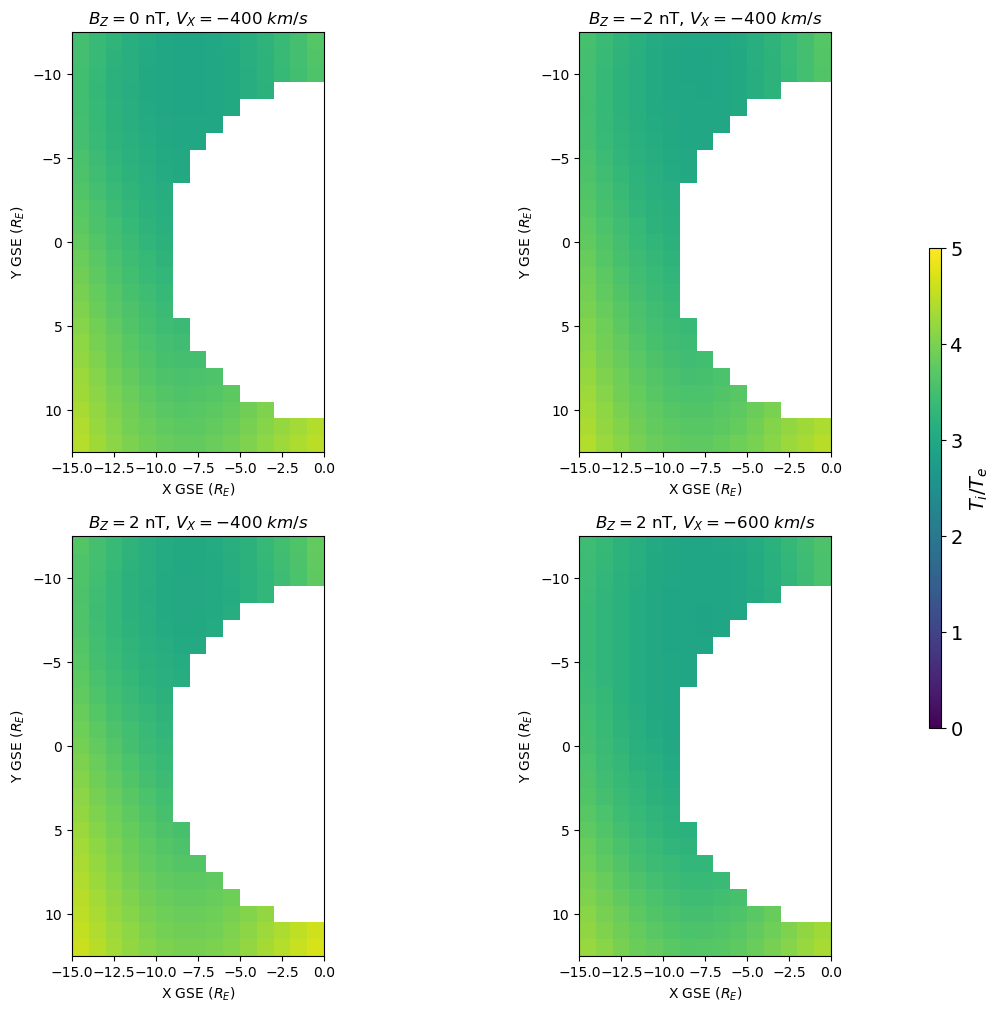

In [64]:
fig, axes = plt.subplots(2, 2, figsize = (12, 12))
for idx, ax in enumerate(axes.flatten()):
    im = ax.imshow((output_grid[idx,:,:,4].T), aspect = 'equal', extent = (x_extent[0], x_extent[1], y_extent[1], y_extent[0]), cmap = 'viridis', vmin = 0, vmax = 5) #, interpolation = 'gaussian')
    # im = ax.imshow(output_grid[idx,:,:,2].T/1000, aspect = 'equal', extent = (x_extent[0], x_extent[1], y_extent[1], y_extent[0]), cmap = 'viridis', vmin = 0, vmax = 3) #, interpolation = 'gaussian')
    ax.set_xlabel(r'X GSE ($R_{E}$)')
    ax.set_ylabel(r'Y GSE ($R_{E}$)')
    # ax.set_title(r'$B_{Z}=' + str(bz[idx]) + r'$ nT, $n_{i}=' + str(ni[idx]) + r'$ $cm^{-3}$')
    ax.set_title(r'$B_{Z}=' + str(bz[idx]) + r'$ nT, $V_{X}=' + str(vx[idx]) + r'$ $km/s$')
    # ax.set_ylim(-15, 15)
cbar_ax = fig.add_axes([0.91, 0.3, 0.01, 0.4])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label(r'$T_{i}/T_{e}$', fontsize=14)
cbar.ax.tick_params(labelsize=14)

In [ ]:
# np.save('psflex_version3_2D.npy', output_grid)

In [ ]:
# Test what embeddings look like for synthetic and non-synthetic data
in_scaled_wind = wind_data.loc[:, model.in_norm.keys()].copy() # Get just the keys used for prediction
for feature in model.in_norm.keys(): # Scale each input feature DOWN
    in_scaled_wind[feature] = (in_scaled_wind[feature] - model.in_norm[feature][0])/model.in_norm[feature][1]

# Turn in_scaled into a numpy array of the correct shape
in_arr_wind = np.zeros((len(positions) - model.window, model.window, len(model.in_norm.keys())))
for i, idx in enumerate(in_scaled_wind.index):
    if i < model.window:
        continue
    in_arr_wind[i - model.window, :, :] = in_scaled_wind.loc[(idx - model.window - model.stride):(idx - model.stride - 1), :]

in_scaled_synth = synth_data.loc[:, model.in_norm.keys()].copy() # Get just the keys used for prediction
for feature in model.in_norm.keys(): # Scale each input feature DOWN
    in_scaled_synth[feature] = (in_scaled_synth[feature] - model.in_norm[feature][0])/model.in_norm[feature][1]

# Turn in_scaled into a numpy array of the correct shape
in_arr_synth = np.zeros((len(synth_pos) - model.window, model.window, len(model.in_norm.keys())))
for i, idx in enumerate(in_scaled_synth.index):
    if i < model.window:
        continue
    in_arr_synth[i - model.window, :, :] = in_scaled_synth.loc[(idx - model.window - model.stride):(idx - model.stride - 1), :]

pos_scaled_wind = positions.iloc[model.window:].loc[:, model.pos_norm.keys()].copy() # Get just the position elements
for feature in model.pos_norm.keys(): # Scale each position DOWN
    pos_scaled_wind[feature] = (pos_scaled_wind[feature] - model.pos_norm[feature][0])/model.pos_norm[feature][1]

synth_pos[datamodule.position_features[0]] = -15
synth_pos[datamodule.position_features[1]] = 0
pos_scaled_synth = synth_pos.iloc[model.window:].loc[:, model.pos_norm.keys()].copy() # Get just the position elements
for feature in model.pos_norm.keys(): # Scale each position DOWN
    pos_scaled_synth[feature] = (pos_scaled_synth[feature] - model.pos_norm[feature][0])/model.pos_norm[feature][1]

# Tensor-ify the inputs from pandas dataframes
in_tensor_wind = torch.from_numpy(in_arr_wind.astype(np.float32)).to(model.device)
in_tensor_synth = torch.from_numpy(in_arr_synth.astype(np.float32)).to(model.device)
pos_tensor_wind = torch.from_numpy(pos_scaled_wind.to_numpy().astype(np.float32)).to(model.device)
pos_tensor_synth = torch.from_numpy(pos_scaled_synth.to_numpy().astype(np.float32)).to(model.device)

In [23]:
embeddings_wind, h_wind = model.encoder.forward(in_tensor_wind)
embeddings_synth, h_synth = model.encoder.forward(in_tensor_synth)

In [26]:
embeddings_synth.shape

torch.Size([1, 200, 256])

Text(0.5, 1.0, 'Wind data')

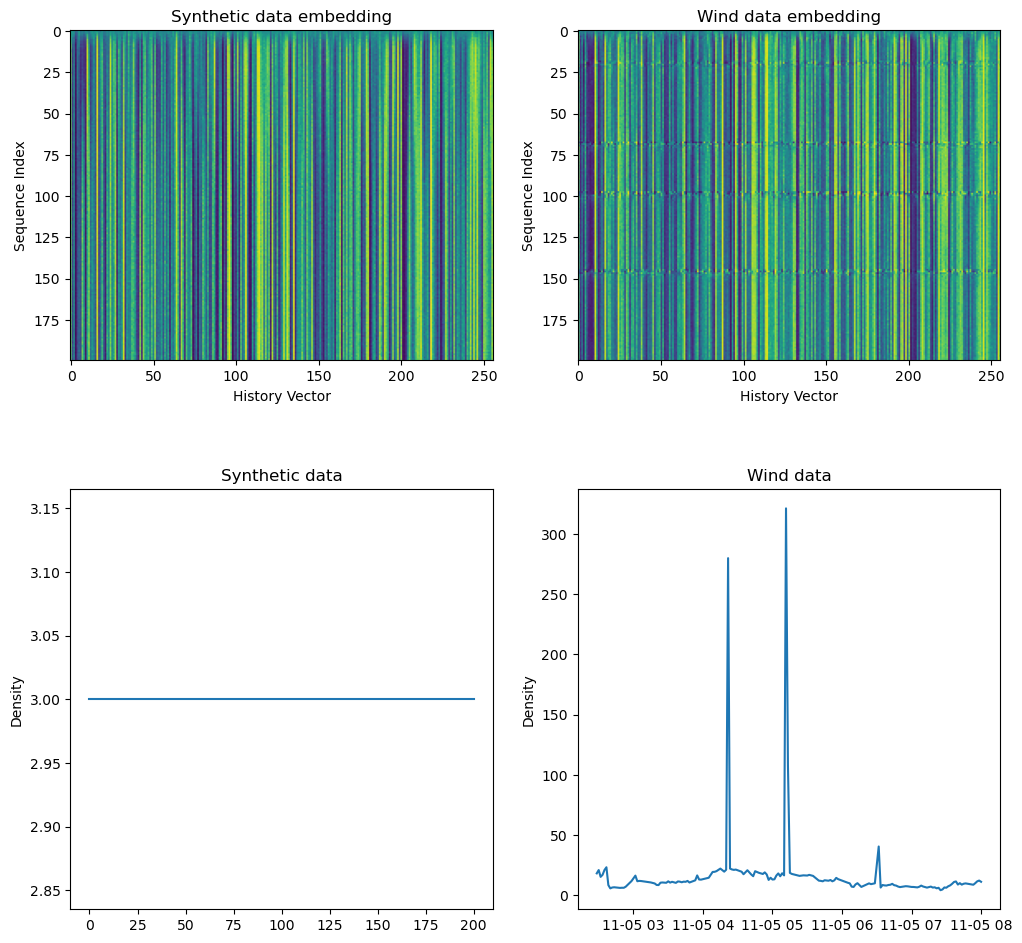

In [45]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (12, 12))

ax[0, 0].imshow(embeddings_synth.cpu().detach().numpy()[0,:,:])
ax[0, 0].set_ylabel(f"Sequence Index")
ax[0, 0].set_xlabel(f"History Vector")
ax[0, 0].set_title(f"Synthetic data embedding")

ax[0, 1].imshow(embeddings_wind.cpu().detach().numpy()[0,:,:])
ax[0, 1].set_ylabel(f"Sequence Index")
ax[0, 1].set_xlabel(f"History Vector")
ax[0, 1].set_title(f"Wind data embedding")

ax[1, 0].plot(np.arange(len(synth_data['Ni'])), synth_data['Ni'])
ax[1, 0].set_ylabel(f"Density")
ax[1, 0].set_title(f"Synthetic data")

ax[1, 1].plot(wind_data.iloc[:model.window, :]['Epoch'], wind_data.iloc[:model.window, :]['Ni'])
ax[1, 1].set_ylabel(f"Density")
ax[1, 1].set_title(f"Wind data")

In [12]:
store = pd.HDFStore("/glade/u/home/cobrien/data/magnetotail/resampled_datasets.h5", mode = 'r')
store.keys()

['/geotail_flexible_100s',
 '/geotail_strict_100s',
 '/geotail_stricthighdensity_100s',
 '/mms_temperatures_proc_v2_100s',
 '/wind_full']

In [14]:
store['mms_temperatures_proc_v2_100s'].columns

Index(['time', 'mms_time', 'class', 'vel_perp_x', 'Vx', 'Vy', 'Vz', 'N', 'T_i',
       'T_e', 'r_gse_x', 'r_gse_y', 'r_gse_z', 'b_gse_x', 'b_gse_y', 'b_gse_z',
       'T_i_over_T_e', 'r_gsm_x', 'r_gsm_y', 'r_gsm_z', 'b_gsm_x', 'b_gsm_y',
       'b_gsm_z', 'Epoch', 'modified_named_label', 'input_idx'],
      dtype='object')

In [14]:
testdata = pd.read_hdf("/glade/u/home/cobrien/prime/scripts/primeps_outputs.h5", key = "psmms_version4", mode = 'a')
# # testdata2 = pd.read_hdf("/glade/u/home/cobrien/prime/scripts/primeps_outputs.h5", key = "psmms_version2")
targets = pd.read_hdf("/glade/u/home/cobrien/data/magnetotail/resampled_datasets.h5", key = "mms_temperatures_proc_v2_100s")
# targets.index = targets['Epoch']
# testdata['Epoch'] = pd.to_datetime(testdata['Epoch'], utc = True)
# # testdata2['Epoch'] = pd.to_datetime(testdata2['Epoch'], utc = True)
# testdata = testdata.join(targets, on = 'Epoch', how = 'left', rsuffix='_target2')
# # testdata2 = testdata2.join(targets, on = 'Epoch', how = 'left', rsuffix='_target')
# testdata = pd.read_hdf("/glade/u/home/cobrien/prime/scripts/primeps_outputs.h5", key = "pshigh_version24")
# olddata = pd.read_hdf("/glade/u/home/cobrien/prime/prime_lib/notebooks/primeps_outputs_oldtemp.h5", key = "psstrict20_version2")
# targets = pd.read_hdf("/glade/u/home/cobrien/data/magnetotail/resampled_datasets.h5", key = "geotail_stricthighdensity_100s")
targets.index = targets['Epoch']
testdata['Epoch'] = pd.to_datetime(testdata['Epoch'], utc = True)
# olddata['Epoch'] = pd.to_datetime(olddata['Epoch'], utc = True)
testdata = testdata.join(targets, on = 'Epoch', how = 'left', rsuffix='_target2')
# olddata = olddata.join(targets, on = 'Epoch', how = 'left', rsuffix='_target2')

import pickle
predictions = np.load('/glade/u/home/cobrien/data/prime/debug_packet/predictions.npy')
targets = np.load('/glade/u/home/cobrien/data/prime/debug_packet/targets.npy')
# val_times = pickle.load('/glade/u/home/cobrien/data/prime/debug_packet/val_times.pkl')
# in_norm = pickle.load('/glade/u/home/cobrien/data/prime/debug_packet/in_norm.pkl')
# tar_norm = pickle.load('/glade/u/home/cobrien/data/prime/debug_packet/tar_norm.pkl')
# pos_norm = pickle.load('/glade/u/home/cobrien/data/prime/debug_packet/pos_norm.pkl')

(-0.4176030522938477, 12.19442658593021)

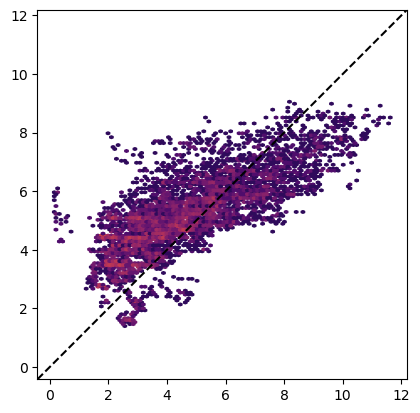

In [19]:
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
plt.hexbin(
    testdata['T_i_target2']/1000,
    testdata['T_i']/1000,
    # (targets[:, 0] * model.tar_norm['T_i'][1]) + model.tar_norm['T_i'][0],
    # (predictions[:, 0] * model.tar_norm['T_i'][1]) + model.tar_norm['T_i'][0],
    norm = LogNorm(1e0, 1e3),
    bins = 50,
    cmap = 'inferno', # TODO: make a fun new colormap
)
lims = [
    np.min([plt.gca().get_xlim(), plt.gca().get_ylim()]),  # min of both axes
    np.max([plt.gca().get_xlim(), plt.gca().get_ylim()]),  # max of both axes
]
plt.plot(
    lims,
    lims,
    color="k",
    linestyle = "--",
)
plt.gca().set_aspect('equal')
plt.gca().set_xlim(lims)
plt.gca().set_ylim(lims)

(-2919.8022705078124, 12194.42658593021)

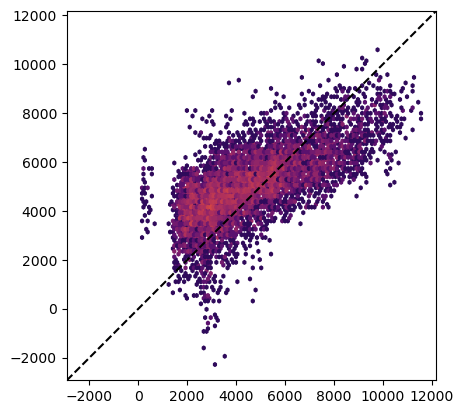

In [19]:
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
plt.hexbin(
    testdata2['T_i_target'],
    testdata2['T_i'],
    norm = LogNorm(1e0, 1e3),
    bins = 50,
    cmap = 'inferno', # TODO: make a fun new colormap
)
lims = [
    np.min([plt.gca().get_xlim(), plt.gca().get_ylim()]),  # min of both axes
    np.max([plt.gca().get_xlim(), plt.gca().get_ylim()]),  # max of both axes
]
plt.plot(
    lims,
    lims,
    color="k",
    linestyle = "--",
)
plt.gca().set_aspect('equal')
plt.gca().set_xlim(lims)
plt.gca().set_ylim(lims)

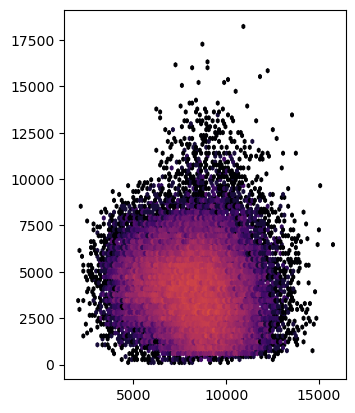

In [14]:
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
plt.hexbin(
    olddata['temp'],
    olddata['temp_target2'],
    norm = LogNorm(1e0, 1e3),
    cmap = 'inferno', # TODO: make a fun new colormap
)
plt.gca().set_aspect('equal')

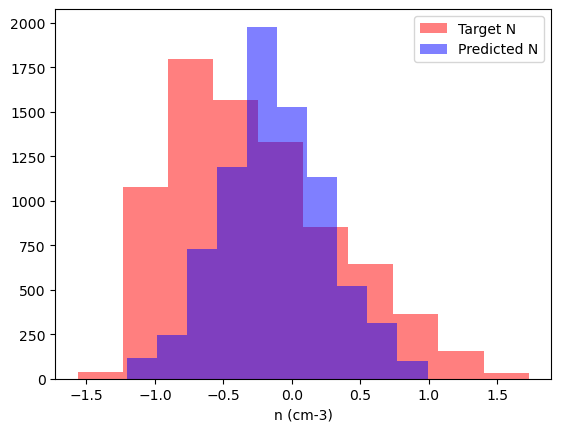

In [24]:
# plt.hist(testdata['N_target'], color = 'r', alpha = 0.5, label = 'Target N')
# plt.hist(testdata['N'], color = 'b', alpha = 0.5, label = 'Predicted N')
plt.hist(targets[:,0], color = 'r', alpha = 0.5, label = 'Target N')
plt.hist(predictions[:,0], color = 'b', alpha = 0.5, label = 'Predicted N')
plt.xlabel('n (cm-3)')
plt.legend()